In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
#from sklearn.preprocessing import OrdinalEncoder
#from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
#import xgboost


In [15]:
df = pd.read_csv('../bank-additional-full.csv', sep=';')

df = df.drop('duration', axis=1)

y = df['y'].map({'yes': 1, 'no': 0})
X = df.drop('y', axis=1)

#finding categorical and numeric variables
categorical_cols = X.select_dtypes(include='object').columns
numeric_cols = X.select_dtypes(exclude='object').columns

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)


Categorical columns: Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')
Numeric columns: Index(['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')


In [16]:
# Convert categorical columns to category dtype for XGBoost
for col in categorical_cols:
    X[col] = X[col].astype('category')

In [17]:
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    enable_categorical=True,
    random_state=1,
    use_label_encoder=False
)

In [18]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}



In [19]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)



In [20]:
#grid search with 5 fold cross validation
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring='f1'
)

#fitting the model
grid_search.fit(X_train, y_train)



Fitting 5 folds for each of 48 candidates, totalling 240 fits


/Users/iankwak/Documents/Bank_Marketing_ML/src/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [14:51:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/iankwak/Documents/Bank_Marketing_ML/src/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [14:51:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/iankwak/Documents/Bank_Marketing_ML/src/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [14:51:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/iankwak/Documents/Bank_Marketing_ML/src/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [14:51:07] WARNING: /Users/runner/work/xgboost/xgboost/src

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True,
                                     eval_metric='logloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=N...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=1, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200], 'subsample': [0.8, 1.0]},
             scoring='f1', verbose=1)

In [21]:
#these are the best parameters
print("Best parameters found:", grid_search.best_params_)

#assigning the best model
best_model = grid_search.best_estimator_

#these are the predictions
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

#evaluation
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))



Best parameters found: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}

Accuracy: 0.899368778829813

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.98      0.95      7310
           1       0.61      0.30      0.40       928

    accuracy                           0.90      8238
   macro avg       0.76      0.64      0.67      8238
weighted avg       0.88      0.90      0.88      8238


Confusion Matrix:
 [[7130  180]
 [ 649  279]]


AUC: 0.7907443305108732


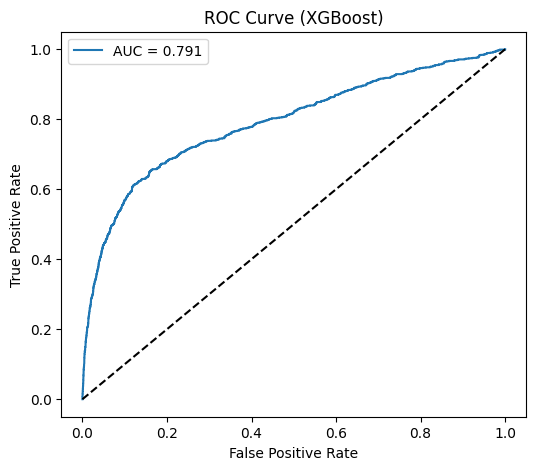

In [22]:
#ROC/AUC and plotting it
auc = roc_auc_score(y_test, y_proba)
print("AUC:", auc)

fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (XGBoost)')
plt.legend()
plt.show()

##using shap to find feature importance

In [23]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Calculating SHAP values for feature importance
sample_size = 2000  # Limiting sample size for computational efficiency
X_sample = X_test.iloc[:sample_size]
y_sample = y_test.iloc[:sample_size]

# No transformation needed - XGBoost handles categorical features natively
# Just use the raw data
X_test_sample = X_sample

# Feature names are just the column names from X
feature_names = list(X_test_sample.columns)

# Calculate SHAP values using the model directly (not through pipeline)
print("Calculating SHAP values...")
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_sample)

# Handle different SHAP output formats
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]  # For binary classification, class 1 (positive class)
else:
    shap_values_class1 = shap_values

# Debugging: check shapes
print(f"Shape of shap_values_class1: {shap_values_class1.shape}")
print(f"Shape of X_test_sample: {X_test_sample.shape}")
print(f"Number of features: {len(feature_names)}")

# Ensure 2D shape
if len(shap_values_class1.shape) == 3:
    # If it's 3D, take the values for class 1
    shap_values_class1 = shap_values_class1[:, :, 1]
    print(f"Converted to 2D shape: {shap_values_class1.shape}")

# Calculate mean absolute SHAP value for each feature
mean_abs_shap = np.abs(shap_values_class1).mean(axis=0)

print(f"\nShape of mean_abs_shap: {mean_abs_shap.shape}")
print(f"Length of feature_names: {len(feature_names)}")

# Create DataFrame for feature importance
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': mean_abs_shap
}).sort_values('importance', ascending=False)

# Display top N features
top_n = 20
top_features = feature_importance.head(top_n)

print(f"\nTop {top_n} most important features:")
print("="*70)
for i, row in enumerate(top_features.itertuples(), 1):
    print(f"{i:>2}. {row.feature:<45} {row.importance:.6f}")

Calculating SHAP values...
Shape of shap_values_class1: (2000, 19)
Shape of X_test_sample: (2000, 19)
Number of features: 19

Shape of mean_abs_shap: (19,)
Length of feature_names: 19

Top 20 most important features:
 1. nr.employed                                   0.503853
 2. emp.var.rate                                  0.232442
 3. contact                                       0.225303
 4. month                                         0.224566
 5. euribor3m                                     0.182743
 6. job                                           0.151279
 7. age                                           0.148499
 8. day_of_week                                   0.147276
 9. campaign                                      0.126228
10. education                                     0.126195
11. pdays                                         0.089550
12. housing                                       0.058276
13. marital                                       0.053044
14. default     


 Saved: XGBoost_feature_importance_top20.png


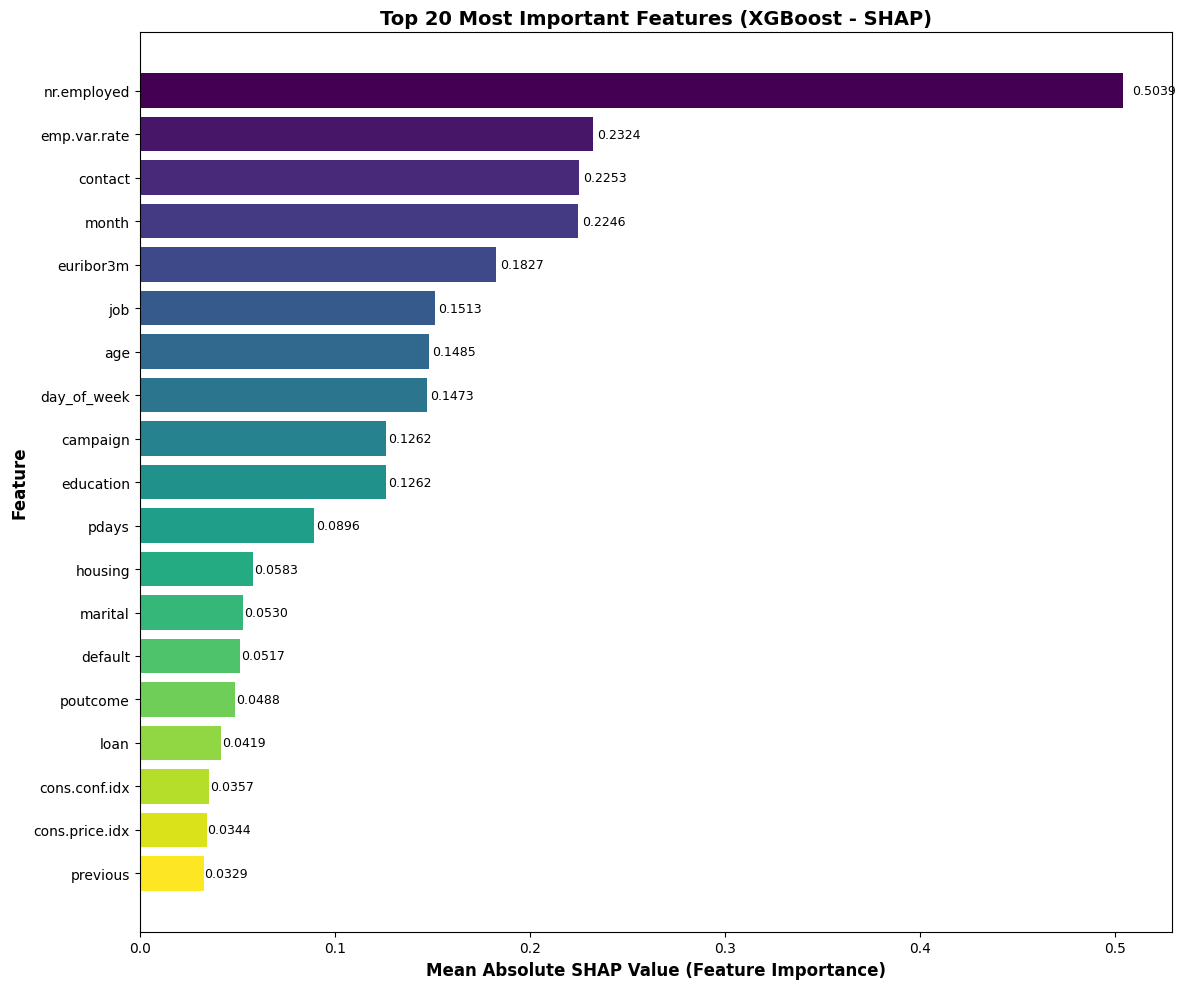

 Saved: XGBoost_all_feature_importance.csv (all 19 features)

SUMMARY
Total features analyzed: 19
Most important feature: nr.employed
Importance range: 0.032876 to 0.503853

In top 20:
  Categorical features: 10
  Numerical features: 9


In [24]:
#plot bar chart of top features
plt.figure(figsize=(12, 10))
colors = plt.cm.viridis(np.linspace(0, 1, len(top_features)))
bars = plt.barh(range(len(top_features)), top_features['importance'], color=colors)
plt.yticks(range(len(top_features)), top_features['feature'], fontsize=10)
plt.xlabel('Mean Absolute SHAP Value (Feature Importance)', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.title(f'Top {top_n} Most Important Features (XGBoost - SHAP)', 
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

#add value labels to bars
for i, (bar, val) in enumerate(zip(bars, top_features['importance'])):
    plt.text(val + val*0.01, i, f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'output/XGBoost_feature_importance_top{top_n}.png', dpi=300, bbox_inches='tight')
print(f"\n Saved: XGBoost_feature_importance_top{top_n}.png")
plt.show()

#save all feature importances to CSV
feature_importance.to_csv('output/XGBoost_all_feature_importance.csv', index=False)
print(f" Saved: XGBoost_all_feature_importance.csv (all {len(feature_importance)} features)")

#print summary statistics
print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"Total features analyzed: {len(feature_names)}")
print(f"Most important feature: {top_features.iloc[0]['feature']}")
print(f"Importance range: {feature_importance['importance'].min():.6f} to {feature_importance['importance'].max():.6f}")

# Show categorical vs numerical breakdown
categorical_count = sum(1 for f in top_features['feature'] if f in categorical_cols)
numerical_count = sum(1 for f in top_features['feature'] if f in numeric_cols)
print(f"\nIn top {top_n}:")
print(f"  Categorical features: {categorical_count}")
print(f"  Numerical features: {numerical_count}")